Exercise 1- Conceptual Questions

1. DQN vs. REINFORCE

In DQN, the neural network outputs Q-values for each possible action. The agent then selects the action with the highest Q-value
In REINFORCE, the neural network outputs a probability distribution over actions. The agent samples an action based on these probabilities


2. The Log-Probability Term

We use the logarithm because it simplifies the gradient computation. The derivative of log(x) is 1/x, which makes the math more stable
Also, using log allows us to convert multiplication of probabilities into sums, which is easier to optimize and avoids numerical instability


3. High Variance

REINFORCE has high variance because it uses the total reward from an entire episode to update each action
An action taken early in the episode might not be responsible for the final outcome. For example, a good action early could still lead to failure later due to bad actions
This makes the learning signal noisy and unstable

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

env = gym.make('CartPole-v1')

In [2]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)
        
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return self.softmax(x)

In [3]:
def select_action(policy, state):
    state = torch.FloatTensor(state)
    
    probs = policy(state)
    dist = torch.distributions.Categorical(probs)
    
    action = dist.sample()
    log_prob = dist.log_prob(action)
    
    return action.item(), log_prob

In [5]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

policy = PolicyNetwork(state_size, action_size)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

gamma = 0.99
episodes = 1000

reward_history = []

for episode in range(episodes):
    state, _ = env.reset()
    
    log_probs = []
    rewards = []
    
    done = False
    
    while not done:
        action, log_prob = select_action(policy, state)
        
        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        log_probs.append(log_prob)
        rewards.append(reward)
        
        state = new_state
    
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    returns = torch.tensor(returns)
    
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    
    loss = []
    for log_prob, G in zip(log_probs, returns):
        loss.append(-log_prob * G)
    
    loss = torch.stack(loss).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    total_reward = sum(rewards)
    reward_history.append(total_reward)
    
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1}, Reward: {total_reward}")

env.close()

Episode 50, Reward: 30.0
Episode 100, Reward: 9.0
Episode 150, Reward: 10.0
Episode 200, Reward: 10.0
Episode 250, Reward: 10.0
Episode 300, Reward: 10.0
Episode 350, Reward: 9.0
Episode 400, Reward: 10.0
Episode 450, Reward: 9.0
Episode 500, Reward: 9.0
Episode 550, Reward: 10.0
Episode 600, Reward: 9.0
Episode 650, Reward: 10.0
Episode 700, Reward: 9.0
Episode 750, Reward: 9.0
Episode 800, Reward: 10.0
Episode 850, Reward: 10.0
Episode 900, Reward: 10.0
Episode 950, Reward: 10.0
Episode 1000, Reward: 10.0


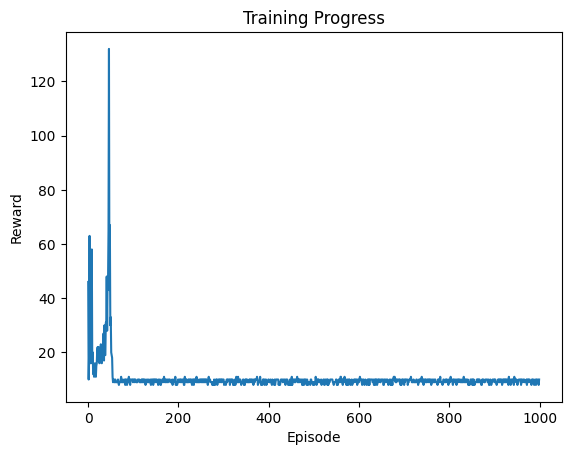

In [6]:
import matplotlib.pyplot as plt

plt.plot(reward_history)
plt.title("Training Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In [7]:
running_avg = 0
beta = 0.9

reward_history_baseline = []

policy = PolicyNetwork(state_size, action_size)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

for episode in range(episodes):
    state, _ = env.reset()
    
    log_probs = []
    rewards = []
    
    done = False
    
    while not done:
        action, log_prob = select_action(policy, state)
        
        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        log_probs.append(log_prob)
        rewards.append(reward)
        
        state = new_state
    
    total_reward = sum(rewards)
    
    running_avg = beta * running_avg + (1 - beta) * total_reward
    
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    returns = torch.tensor(returns)
    
    loss = []
    for log_prob, G in zip(log_probs, returns):
        loss.append(-log_prob * (G - running_avg))
    
    loss = torch.stack(loss).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    reward_history_baseline.append(total_reward)

env.close()

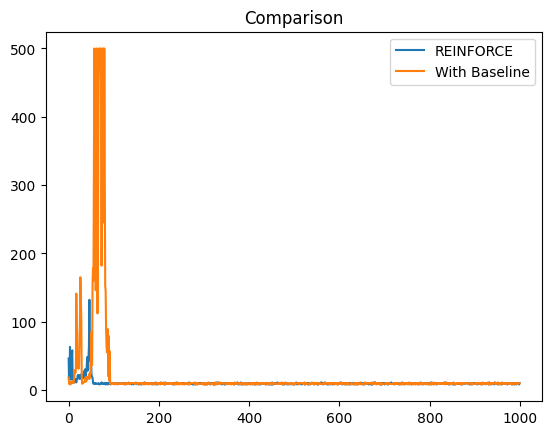

In [8]:
plt.plot(reward_history, label="REINFORCE")
plt.plot(reward_history_baseline, label="With Baseline")
plt.legend()
plt.title("Comparison")
plt.show()

The baseline version shows more stable learning
By subtracting the average reward, we reduce variance in the updates
This helps the model converge faster and avoid large fluctuations